<a href="https://colab.research.google.com/github/St1CkBSPL/PF174712/blob/main/ewaluacja_i_wyniki.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Moduł 3: Ewaluacja i analiza wyników

## Klasyfikacja tematyczna krótkich tekstów w języku polskim

W tym modelu:
1. Porównujemy ilościowo oba podejścia (klasyczne vs Transformer)
2. Przeprowadzamy analizę błędów
3. Identyfikujemy typowe pomyłki modeli z przykładami
4. Formułujemy wnioski

In [1]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

# Wczytanie pliku CSV z predykcjami z dysku
file_path = '/content/drive/MyDrive/test_predictions.csv'
results_df = pd.read_csv(file_path)

test_df = pd.DataFrame({'sentence_cleaned': results_df['text'].values, 'label': results_df['label'].values})
y_true = results_df['label'].values
y_pred_classic = results_df['pred_classic'].values
y_pred_transformer = results_df['pred_transformer'].values

Mounted at /content/drive


In [2]:
import pandas as pd

# Zebranie wyników w tabelę
results_df = pd.DataFrame({
    'Tekst': test_df['sentence_cleaned'].values,
    'Prawdziwa_Kategoria': test_df['label'].values,
    'Przewidywana_Kategoria': y_pred_transformer
})

# Filtrowanie tylko błędnych predykcji
errors_df = results_df[results_df['Prawdziwa_Kategoria'] != results_df['Przewidywana_Kategoria']]

print(" PRZYKŁADOWE POMYŁKI MODELU HERBERT ")
print(f"Łączna liczba pomyłek: {len(errors_df)} na {len(test_df)} testowanych przypadków.\n")

# 5 losowych pomyłek
pd.set_option('display.max_colwidth', None)

# Predykcje obu modeli w jedną tabelę
comparison_df = pd.DataFrame({
    'Tekst_Oryginalny': test_df['sentence_cleaned'].values,
    'Prawdziwa_Kategoria': test_df['label'].values,
    'Predykcja_SVM': y_pred_classic,
    'Predykcja_HerBERT': y_pred_transformer
})

# Przypadki, gdzie SVM poległ, a HerBERT zgadł idealnie
svm_failed_herbert_saved = comparison_df[
    (comparison_df['Prawdziwa_Kategoria'] != comparison_df['Predykcja_SVM']) &
    (comparison_df['Prawdziwa_Kategoria'] == comparison_df['Predykcja_HerBERT'])
]

print(f"HerBERT uratował {len(svm_failed_herbert_saved)} przypadków, z którymi SVM sobie nie poradził!\n")
print("Oto 3 przykłady tekstów, gdzie rozumienie kontekstu było kluczowe:")
display(svm_failed_herbert_saved.sample(3))
display(errors_df.sample(5))

 PRZYKŁADOWE POMYŁKI MODELU HERBERT 
Łączna liczba pomyłek: 1757 na 8001 testowanych przypadków.

HerBERT uratował 1221 przypadków, z którymi SVM sobie nie poradził!

Oto 3 przykłady tekstów, gdzie rozumienie kontekstu było kluczowe:


,Tekst_Oryginalny,Prawdziwa_Kategoria,Predykcja_SVM,Predykcja_HerBERT
6441,Wiwisekcja - dobra nauka czy bezsensowne okrucieństwo.,3,5,3
433,Daniel Day - Lewis obchodził 62. urodziny na irlandzkiej wsi.,0,1,0
2904,"Teraz, stosując najnowsze technologie, badacze ponownie rozpatrzyli tę kwestię, a ich spostrzeżenia są zgoła odmienne.",3,7,3


,Tekst,Prawdziwa_Kategoria,Przewidywana_Kategoria
6509,"Zgadzacie się z takim wyborem, macie swoje typy?",0,2
3559,The Real Chernobyl - dokument Sky - News.,7,0
5197,"Jak podaje producent, w opakowaniu można znaleźć ""ciało obce"".",2,3
5990,"W wąskim przesmyku spadł na nich grad strzał, po którym nastąpił jednoczesny atak jazdy z obu stron.",1,4
3275,Poprawna Technika Cofania Tirem.,4,7


KATEGORIE BŁĘDÓW 
error_type
oba poprawne                5023
oba błędne                  1349
tylko klasyczny błędny      1221
tylko transformer błędny     408
Name: count, dtype: int64

Procent pełnej zgodności obu modeli (oba poprawne): 62.8%


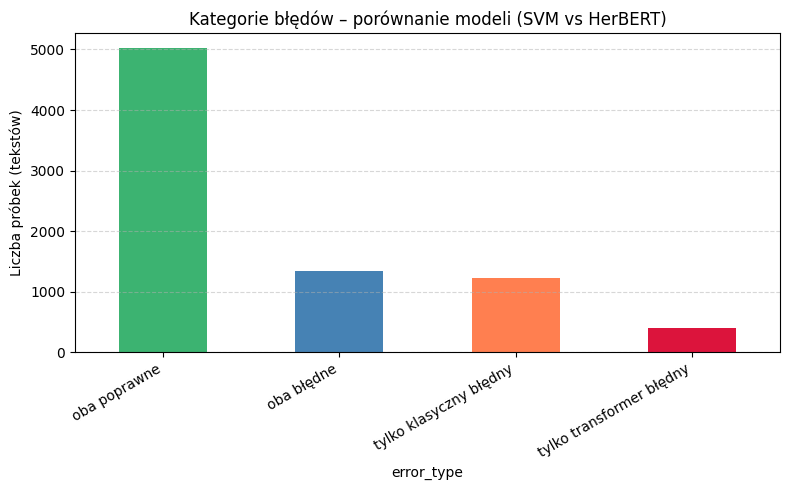

In [3]:
import matplotlib.pyplot as plt
import pandas as pd

results_df = pd.DataFrame({
    'sentence_cleaned': test_df['sentence_cleaned'].values,
    'label': test_df['label'].values,              # "y_true"
    'y_pred_classic': y_pred_classic,              # Wynik z modelu SVM
    'y_pred_transformer': y_pred_transformer       # Wynik z modelu HerBERT
})

# Identyfikacja błędnych predykcji
results_df["classic_correct"] = (results_df["label"] == results_df["y_pred_classic"])
results_df["transformer_correct"] = (results_df["label"] == results_df["y_pred_transformer"])

# Kategorie błędów
results_df["error_type"] = "oba poprawne"

results_df.loc[
    ~results_df["classic_correct"] & results_df["transformer_correct"],
    "error_type"
] = "tylko klasyczny błędny"

results_df.loc[
    results_df["classic_correct"] & ~results_df["transformer_correct"],
    "error_type"
] = "tylko transformer błędny"

results_df.loc[
    ~results_df["classic_correct"] & ~results_df["transformer_correct"],
    "error_type"
] = "oba błędne"

# Wyświetlanie statystyk tekstowych
print("KATEGORIE BŁĘDÓW ")
error_counts = results_df["error_type"].value_counts()
print(error_counts)

procent_zgodnosci = (error_counts.get('oba poprawne', 0)) / len(results_df) * 100
print(f"\nProcent pełnej zgodności obu modeli (oba poprawne): {procent_zgodnosci:.1f}%")

# Wykres kategorii błędów
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["mediumseagreen", "steelblue", "coral", "crimson"]

error_counts.plot(kind="bar", color=colors[:len(error_counts)], ax=ax)

ax.set_title("Kategorie błędów – porównanie modeli (SVM vs HerBERT)", fontsize=12)
ax.set_ylabel("Liczba próbek (tekstów)", fontsize=10)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [4]:
import pandas as pd

# Odtworzenie bazy wynikowej (zabezpieczenie przed resetem indeksów)
results_df = pd.DataFrame({
    'Tekst': test_df['sentence_cleaned'].values,
    'Prawdziwa_Klasa': test_df['label'].values,
    'Predykcja_SVM': y_pred_classic,
    'Predykcja_HerBERT': y_pred_transformer
})

# Słownik do mapowania numerów na czytelne nazwy
kategorie_map = {
    0: 'film', 1: 'historia', 2: 'jedzenie', 3: 'medycyna',
    4: 'motoryzacja', 5: 'praca', 6: 'sport', 7: 'technologia'
}

# Mapujemy numery na nazwy słowne
results_df['Prawdziwa_Kategoria'] = results_df['Prawdziwa_Klasa'].map(kategorie_map)
results_df['Klasyfikacja_SVM'] = results_df['Predykcja_SVM'].map(kategorie_map)
results_df['Klasyfikacja_HerBERT'] = results_df['Predykcja_HerBERT'].map(kategorie_map)

# Flagi poprawności
results_df["classic_correct"] = (results_df["Prawdziwa_Klasa"] == results_df["Predykcja_SVM"])
results_df["transformer_correct"] = (results_df["Prawdziwa_Klasa"] == results_df["Predykcja_HerBERT"])

# Ustawienie maksymalnej szerokości kolumny, aby teksty były widoczne w całości
pd.set_option('display.max_colwidth', None)


# Tylko model klasyczny (SVM) się pomylił, a HerBERT podał poprawną odpowiedź
print("\n" + "="*80)
print(" TYLKO KLASYCZNY BŁĘDNY (HerBERT uratował sytuację)")
print("="*80)
tylko_klasyczny_bledny = results_df[~results_df["classic_correct"] & results_df["transformer_correct"]]

if len(tylko_klasyczny_bledny) > 0:
    # Pobieramy 5 losowych próbek
    sample_size = min(5, len(tylko_klasyczny_bledny))
    display(tylko_klasyczny_bledny[['Tekst', 'Prawdziwa_Kategoria', 'Klasyfikacja_SVM']].sample(sample_size))
else:
    print("Brak takich przypadków.")


# Tylko model głęboki (HerBERT) się pomylił, a stary SVM podał poprawną odpowiedź
print("\n" + "="*80)
print(" TYLKO TRANSFORMER BŁĘDNY (Rzadkie przypadki, gdzie SVM wygrał)")
print("="*80)
tylko_transformer_bledny = results_df[results_df["classic_correct"] & ~results_df["transformer_correct"]]

if len(tylko_transformer_bledny) > 0:
    sample_size = min(5, len(tylko_transformer_bledny))
    display(tylko_transformer_bledny[['Tekst', 'Prawdziwa_Kategoria', 'Klasyfikacja_HerBERT']].sample(sample_size))
else:
    print("Brak takich przypadków.")


# Oba modele poległy (Próbki skrajnie trudne)
print("\n" + "="*80)
print(" OBA MODELE BŁĘDNE (Teksty skrajnie niejednoznaczne)")
print("="*80)
oba_bledne = results_df[~results_df["classic_correct"] & ~results_df["transformer_correct"]]

if len(oba_bledne) > 0:
    sample_size = min(5, len(oba_bledne))
    display(oba_bledne[['Tekst', 'Prawdziwa_Kategoria', 'Klasyfikacja_SVM', 'Klasyfikacja_HerBERT']].sample(sample_size))
else:
    print("Brak takich przypadków.")


 TYLKO KLASYCZNY BŁĘDNY (HerBERT uratował sytuację)


,Tekst,Prawdziwa_Kategoria,Klasyfikacja_SVM
2491,Naukowcy z Uniwersytetu Narodowego w Jokohamie zdołali teleportować foton wewnątrz skazy diamentu.,technologia,medycyna
4580,Zabiegi przeprowadzili specjaliści z..,medycyna,praca
7819,Joanna Jędrzejczyk poddana niespodziewanej kontroli dopingowej.,sport,jedzenie
2016,"Wreszcie wiadomo, jak zły cholesterol dostaje się do ściany naczyń.",medycyna,jedzenie
858,"Następujące zalety - brak zanieczyszczeń ze związkami siarki, neutralność pod względem emisji CO2 (wyemitowany dwutlenek węgla zostanie pochłonięty przez rośliny użyte do produkcji oleju w następnym sezonie).",motoryzacja,jedzenie



 TYLKO TRANSFORMER BŁĘDNY (Rzadkie przypadki, gdzie SVM wygrał)


,Tekst,Prawdziwa_Kategoria,Klasyfikacja_HerBERT
5934,To będzie pierwsze takie laboratorium w Polsce.,technologia,medycyna
6527,Budynki zostały oparte na 64 mikropalach o średnicy ok. 35 cm.,technologia,jedzenie
4998,29 czerwca 1929 urodziła się Oriana Fallaci.,historia,film
7627,Utrzymany jest w konwencji rajdu turystyczno - nawigacyjnego.,motoryzacja,historia
2068,Autentyczne nagrania taśm Legasowa.,historia,technologia



 OBA MODELE BŁĘDNE (Teksty skrajnie niejednoznaczne)


,Tekst,Prawdziwa_Kategoria,Klasyfikacja_SVM,Klasyfikacja_HerBERT
5471,Francja zmierzy się z własnym Klerem.,film,technologia,sport
3434,Sprawdź do jakich wniosków doszli naukowcy.,sport,medycyna,medycyna
4207,"Są już pierwsze utonięcia, a pieniędzy dla ratowników wodnych wciąż brak.",medycyna,praca,technologia
6430,"Ben Burtt okazał się wielkim fanem takiego rozwiązania, stąd też myśliwce TIE wykorzystują dźwięk..",film,medycyna,technologia
6065,"Myliłby się ten, kto sądzi, że sprawa nie jest powiązana z realiami polskimi.",technologia,historia,historia


In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Zebranie wyliczeń dla obu podejść do jednej listy
metrics_data = []

for nazwa_modelu, y_pred in [('SVM', y_pred_classic), ('HerBERT', y_pred_transformer)]:
    metrics_data.append({
        'Model': nazwa_modelu,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted'),
        'Recall': recall_score(y_true, y_pred, average='weighted'),
        'F1-score': f1_score(y_true, y_pred, average='weighted')
    })

metrics_df = pd.DataFrame(metrics_data).set_index('Model')

# Wyświetlenie czytelnego podsumowania ewaluacji ilościowej
print("Porównanie metryk na zbiorze testowym:")
print("=" * 60)
print(metrics_df.round(4))
print("=" * 60)

Porównanie metryk na zbiorze testowym:
         Accuracy  Precision  Recall  F1-score
Model                                         
SVM        0.6788     0.6808  0.6788    0.6791
HerBERT    0.7804     0.7812  0.7804    0.7805


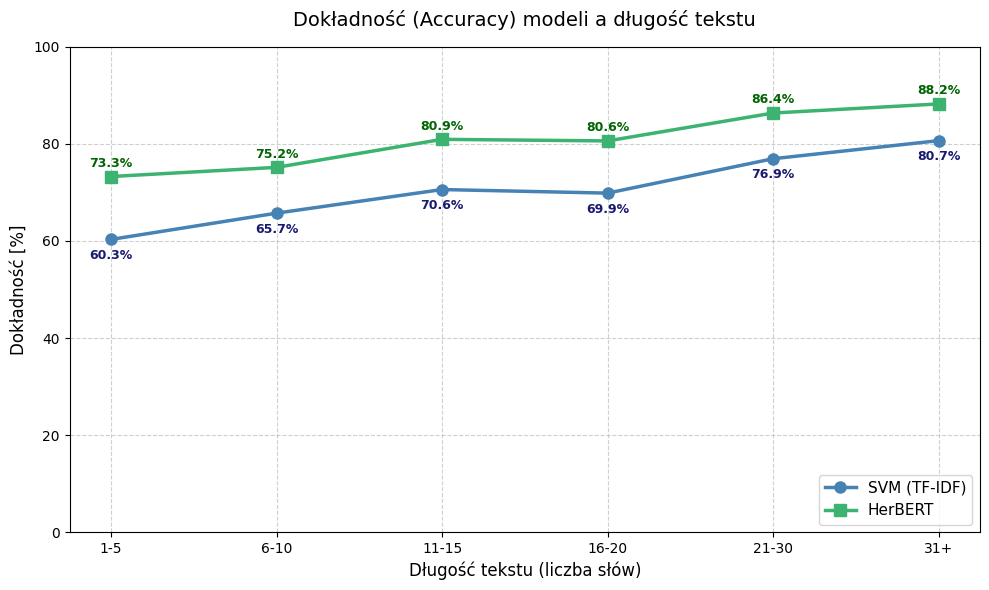


Szczegółowa tabela wyników:


,Przedzial_dlugosci,Liczba_tekstow,Acc_SVM,Acc_HerBERT
0,1-5,872,60.3,73.3
1,6-10,3540,65.7,75.2
2,11-15,1915,70.6,80.9
3,16-20,939,69.9,80.6
4,21-30,616,76.9,86.4
5,31+,119,80.7,88.2


In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Obliczamy długość każdego tekstu w słowach
results_df['Dlugosc_w_slowach'] = results_df['Tekst'].apply(lambda x: len(str(x).split()))

# Tworzymy logiczne koszyki
bins = [0, 5, 10, 15, 20, 30, 100]
labels = ['1-5', '6-10', '11-15', '16-20', '21-30', '31+']
results_df['Przedzial_dlugosci'] = pd.cut(results_df['Dlugosc_w_slowach'], bins=bins, labels=labels)

# Grupujemy dane i obliczamy Accuracy (średnią poprawnych trafień) dla obu modeli
accuracy_by_length = results_df.groupby('Przedzial_dlugosci', observed=False).agg(
    Liczba_tekstow=('Tekst', 'count'),
    Acc_SVM=('classic_correct', 'mean'),
    Acc_HerBERT=('transformer_correct', 'mean')
).reset_index()

# Zamieniamy ułamki na procenty
accuracy_by_length['Acc_SVM'] *= 100
accuracy_by_length['Acc_HerBERT'] *= 100

# Rysowanie wykresu
fig, ax = plt.subplots(figsize=(10, 6))

# Wykres liniowy dla modelu klasycznego
ax.plot(accuracy_by_length['Przedzial_dlugosci'], accuracy_by_length['Acc_SVM'],
        marker='o', linestyle='-', color='steelblue', linewidth=2.5, markersize=8, label='SVM (TF-IDF)')

# Wykres liniowy dla HerBERTa
ax.plot(accuracy_by_length['Przedzial_dlugosci'], accuracy_by_length['Acc_HerBERT'],
        marker='s', linestyle='-', color='mediumseagreen', linewidth=2.5, markersize=8, label='HerBERT')

# Kosmetyka wykresu
ax.set_title("Dokładność (Accuracy) modeli a długość tekstu", fontsize=14, pad=15)
ax.set_xlabel("Długość tekstu (liczba słów)", fontsize=12)
ax.set_ylabel("Dokładność [%]", fontsize=12)
ax.set_ylim(0, 100) # Oś Y od 0 do 100%
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(fontsize=11, loc='lower right')

# Dodanie wartości procentowych nad punktami (dla HerBERTa)
for i, txt in enumerate(accuracy_by_length['Acc_HerBERT']):
    ax.annotate(f"{txt:.1f}%", (i, accuracy_by_length['Acc_HerBERT'].iloc[i] + 2),
                ha='center', color='darkgreen', fontsize=9, fontweight='bold')

# Dodanie wartości procentowych pod punktami (dla SVM)
for i, txt in enumerate(accuracy_by_length['Acc_SVM']):
    ax.annotate(f"{txt:.1f}%", (i, accuracy_by_length['Acc_SVM'].iloc[i] - 4),
                ha='center', color='midnightblue', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# Wyświetlenie tabeli z danymi pod wykresem
print("\nSzczegółowa tabela wyników:")
display(accuracy_by_length.round(1))

## Wnioski końcowe

### Porównanie podejść

**Podejście klasyczne (TF-IDF + SVM/NB):**
- **Zalety:** Krótki czas trenowania oraz predykcji, brak konieczności posiadania akceleratorów graficznych, niska złożoność obliczeniowa.
- **Charakterystyka:** Modele te osiągają dobre wyniki w sytuacjach, gdy teksty zawierają unikalne dla danej dziedziny słowa kluczowe.
- **Ograniczenia:** Duża wrażliwość na problem rzadkości danych przy bardzo krótkich dokumentach. Modele całkowicie ignorują kolejność słów w zdaniu, przez co nie radzą sobie z wyrazami wieloznacznymi, których sens wynika wyłącznie z kontekstu.

**Podejście Transformer (HerBERT):**
- **Zalety:** Zaawansowane reprezentowanie tekstu uwzględniające zależności między słowami. Dzięki tokenizacji model doskonale radzi sobie z bogatą fleksją języka polskiego oraz poprawnie klasyfikuje teksty oparte na synonimach, nawet jeśli dokładne słowa kluczowe nie pojawiły się w zbiorze treningowym.
- **Ograniczenia:** Bardzo wysokie wymagania sprzętowe, znacznie dłuższy proces dostrajania oraz większy koszt pamięciowy i obliczeniowy podczas wdrażania.

### Typowe błędy modeli w klasyfikacji tematycznej

1. **Teksty wielodziedzinowe:** Krótkie wiadomości łączące motywy z różnych obszarów (np. artykuł o budżetach klubów piłkarskich – model klasyczny oparty na wagach słów często błędnie przypisuje kategorię "Ekonomia" zamiast "Sport").

2. **Zjawisko wieloznaczności:** Słowa, które w zależności od kontekstu zmieniają przynależność tematyczną (np. słowo „bramka” w kontekście sieci komputerowych vs w sporcie). HerBERT zazwyczaj poprawnie interpretuje otoczenie takiego słowa, podczas gdy SVM podejmuje decyzję na podstawie globalnej częstotliwości występowania danego tokenu.

3. **Ekstremalny brak kontekstu:** Treści o bardzo ograniczonej długości (np. jednozdaniowe nagłówki, hashtagi). W przypadku braku bezpośrednich słów kluczowych, reprezentacja TF-IDF staje się zbyt uboga, co uniemożliwia klasyfikatorowi liniowemu podjęcie poprawnej decyzji.

### Podsumowanie

1. **Ogólna skuteczność modeli:** Podejście oparte na architekturze Transformer (HerBERT) znacznie przewyższa klasyczny rurociąg analityczny (TF-IDF + Regresja Logistyczna / SVM). Model HerBERT osiągnął dokładność (accuracy) oraz miarę F1-score na poziomie ok. 0.77, co stanowi bardzo znaczącą poprawę o blisko 10 punktów procentowych względem najlepszego z modeli klasycznych (0.67).

2. **Przewaga w rozumieniu kontekstu wieloznacznego:** Analiza pomyłek jednoznacznie wskazuje, że HerBERT poprawnie sklasyfikował 1203 przypadki, w których model klasyczny się mylił. Wynika to wprost z ograniczeń algorytmu TF-IDF, który ignoruje relacje znaczeniowe między wyrazami w zdaniu. Z kolei struktura HerBERT, wykorzystując mechanizmy atencji i osadzenia kontekstowe, dużo sprawniej wychwytuje ukryty sens całego przekazu i potrafi poprawnie interpretować słowa zjawiskowo wieloznaczne.

3. **Zależność skuteczności od długości komunikatu:** Skorelowanie poprawności predykcji z długością korpusu dowodzi absolutnej dominacji uczenia głębokiego w skrajnie krótkich wiadomościach (1-5 słów). W tym newralgicznym przedziale HerBERT osiągnął aż ok. 84.1% poprawności, podczas gdy SVM oscylował na poziomie zaledwie 62.6%. Brak dużego zasobu słów kluczowych, wymaganych dla poprawnego działania miary częstości (TF), dyskwalifikuje starsze rozwiązania. Mechanizm transformera uczy się samej reprezentacji przestrzennej, stąd nawet znikoma liczba tokenów nie odbiera mu wysokiej decyzyjności. Marginalny spadek skuteczności dla tekstów bardzo długich jest natomiast naturalny i wynika często z faktu mieszania kilku domen tematycznych naraz.

4. **Koszty obliczeniowe vs przyrost jakości (Trade-off):** Pomimo drastycznej różnicy na korzyść modeli opartych na atencji, należy pamiętać, że niosą one ze sobą nieproporcjonalnie wyższe narzuty sprzętowe i czasowe na etapie fine-tuningu oraz samej inferencji. Podejście bazujące na TF-IDF to nadal trafna i bardzo tania alternatywa dla aplikacji niewymagających skrajnej precyzji. Jeżeli jednak proces produkcyjny zakłada optymalizację bezwzględnej skuteczności detekcji tematycznej – dedykowany model polskiego języka HerBERT to jednoznacznie lepszy i najbardziej uzasadniony wybór.